In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv("../../Data/house-prices-advanced-regression-techniques/train.csv")
train_data.drop(columns=['Id'], inplace=True)
X_test = pd.read_csv("../../Data/house-prices-advanced-regression-techniques/test.csv")
y_test = pd.read_csv("../../Data/house-prices-advanced-regression-techniques/sample_submission.csv")['SalePrice']
test_data = pd.concat([X_test,y_test], axis=1)
train_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
test_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,169277.052498
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,187758.393989
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,183583.683570
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,179317.477511
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,150730.079977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,167081.220949
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,164788.778231
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,219222.423400
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,184924.279659


In [4]:
X_train, y_train = train_data.iloc[:,:-1], train_data.iloc[:,-1]

In [5]:
df = pd.concat([train_data,test_data],axis=0)
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Id
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.000000,NaN
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.000000,NaN
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.000000,NaN
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.000000,NaN
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,6,2006,WD,Normal,167081.220949,2915.0
1455,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,4,2006,WD,Abnorml,164788.778231,2916.0
1456,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2006,WD,Abnorml,219222.423400,2917.0
1457,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,MnPrv,Shed,700,7,2006,WD,Normal,184924.279659,2918.0


In [6]:
for col in df.columns:
    if df[col].isnull().mean() > 0.6:
        print(col,end=' , ')
        df.drop(columns=[col], inplace=True)

Alley , MasVnrType , PoolQC , Fence , MiscFeature , 

In [7]:
drop_cols = ['Utilities']

In [8]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF

In [9]:
df = pd.concat([train_data, test_data], axis=0)
(df.isnull().mean() * 100)

MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
                   ...    
YrSold            0.000000
SaleType          0.034258
SaleCondition     0.000000
SalePrice         0.000000
Id               50.017129
Length: 81, dtype: float64

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, KBinsDiscretizer, PowerTransformer, LabelEncoder

In [11]:
imp_ohe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe",OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
])

ohe_pipe = Pipeline([
    ("ohe",OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
])


ord1 = Pipeline([
    ("ord",OrdinalEncoder(categories=[['IR3','IR2','IR1','Reg']]))
])
ord2 = Pipeline([
    ("ord",OrdinalEncoder(categories=[['Sev','Mod','Gtl']]))
])
ord3 = Pipeline([
    ("ord",OrdinalEncoder(categories=[['1Fam','2fmCon','Duplex','TwnhsE','Twnhs']]))
])
ord4 = Pipeline([
    ("ord",OrdinalEncoder(categories=[['1Story','1.5Fin','1.5Unf','2Story','2.5Fin','2.5Unf','SFoyer','SLvl']]))
])
ord5 = Pipeline([
    ("ord",OrdinalEncoder(categories=[['Po','Fa','TA','Gd','Ex']]*2 ))
])


imp_ord1 = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=[['NA','Po','Fa','TA','Gd','Ex']]*7))
])
imp_ord2 = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=[['NA','No','Mn','Av','Gd']]))
])
imp_ord3 = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=[['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']]*2))
])
imp_ord4 = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=[['NA','Unf','RFn','Fin']]))
])


imp = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent"))
])


imp_lbl = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("lbl", OrdinalEncoder())
])


In [12]:
std_bin_pow = Pipeline([
    ('bin',KBinsDiscretizer(encode='ordinal')),
    ("std",StandardScaler()),
    ("pow", PowerTransformer())
])
std_pow = Pipeline([
    ("std",StandardScaler()),
    ("pow", PowerTransformer())
])
imp_std_pow = Pipeline([
    ("imp",SimpleImputer()),
    ("std",StandardScaler()),
    ("pow", PowerTransformer())
])
imp_bin_std_pow = Pipeline([
    ("imp",SimpleImputer()),
    ('bin',KBinsDiscretizer(encode='ordinal')),
    ("std",StandardScaler()),
    ("pow", PowerTransformer())
])

In [13]:
%%script false --no-raise-error
categorical_features = [
    'MSZoning', 'Exterior1st', 'Exterior2nd', 'Electrical', 'Functional', 'GarageType', 'SaleType' , 'MasVnrArea'   # Imp - OHE
    'Street', 'LandContour', 'LotConfig','LotConfig' , 'Neighborhood', 'Condition1', 'Condition2', 'RoofStyle', 'RoofMatl', 'Foundation', 'Heating', 'PavedDrive', 'SaleCondition' ,     # OHE 

    {'LotShape' : ['IR3','IR2','IR1','Reg']}, {'LandSlope':['Sev','Mod','Gtl']}, {'BldgType':['1Fam','2FmCon','Duplx','TwnhsE','TwnhsI']}, {'HouseStyle':['1Story','1.5Fin','1.5unf','2Story','2.5Fin','2.5Unf','SFoyer','SLvl']}, {['ExterQual','ExterCond']:['Po','Fa','TA','Gd','Ex']},    # ordinal

    {['BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond']: ['NA','Po','Fa','TA','Gd','Ex']}, {['BsmtExposure']: ['NA','No','Mn','Av','Gd']}, {['BsmtFinType1','BsmtFinType2']:['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']}, {"GarageFinish": ['NA','Unf','RFn','Fin']},  # Imp - ordinal

    'BsmtFullBath', 'BsmtHalfBath' # Imp

    'CentralAir'   # Imp - label

    'FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr' # No change

]
numerical_features = [
    'MSSubClass', 'LotArea', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold'  # Std - Bin - Pow

    'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd' , 'TotRmsAbvGrd', 'Fireplaces', 'MoSold'  # Std - Pow

    'GarageYrBlt', 'GarageCars'   # Imp - Std - Pow                                                                           

    'LotFrontage', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', "GarageArea" # Imp - Std - Bin - Pow
]

Couldn't find program: 'false'


In [14]:
preprocessor = ColumnTransformer(transformers=[
    ("imp_ohe",imp_ohe,['MSZoning', 'Exterior1st', 'Exterior2nd', 'Electrical', 'Functional', 'GarageType', 'SaleType', 'MasVnrArea']),
    ("ohe_pipe",ohe_pipe,['Street', 'LandContour','LotConfig' , 'Neighborhood', 'Condition1', 'Condition2', 'RoofStyle', 'RoofMatl', 'Foundation', 'Heating', 'PavedDrive', 'SaleCondition' ]),
    
    ("ord1",ord1,['LotShape']),
    ("ord2",ord2,['LandSlope']),
    ("ord3",ord3,['BldgType']),
    ("ord4",ord4,['HouseStyle']),
    ("ord5",ord5,['ExterQual','ExterCond']),
    
    ("imp_ord1",imp_ord1,['BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond']),
    ("imp_ord2",imp_ord2,['BsmtExposure']),
    ("imp_ord3",imp_ord3,['BsmtFinType1','BsmtFinType2']),
    ("imp_ord4",imp_ord4,["GarageFinish"]),
    
    ("imp",imp,['BsmtFullBath', 'BsmtHalfBath']),
    ("imp_lbl",imp_lbl,["CentralAir"]),
    
    # Numerical
    ("std_bin_pow",std_bin_pow,['MSSubClass', 'LotArea', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold' ]),
    ("std_pow",std_pow,['OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd' , 'TotRmsAbvGrd', 'Fireplaces', 'MoSold']),
    ("imp_std_pow",imp_std_pow,['GarageYrBlt', 'GarageCars']),
    ("imp_bin_std_pow",imp_bin_std_pow,['LotFrontage', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', "GarageArea"]),
    
])

target_preprocess = StandardScaler()

In [15]:
from sklearn import set_config
set_config(display='diagram')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imp_ohe', ...), ('ohe_pipe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [16]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

F:\Data_Science\DeepPyTorchLight\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
F:\Data_Science\DeepPyTorchLight\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
F:\Data_Science\DeepPyTorchLight\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
F:\Data_Science\DeepPyTorchLight\.venv\Lib\site-packages\sklearn\preprocessing\

In [20]:
y_train = target_preprocess.fit_transform(y_train.values.reshape(-1,1))
y_test = target_preprocess.transform(y_test.values.reshape(-1,1))

In [21]:
X_train.shape

(1460, 507)

In [22]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [23]:
from torch.utils.data import Dataset, DataLoader
import torch

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features =  torch.tensor(features, dtype=torch.float32)
        self.labels =  torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [24]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [25]:
import torch.nn as nn

class AnnModel(nn.Module):
    def __init__(self, X_train):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(768,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 1),
        )
        
    def forward(self, X_train):
        return self.network(X_train)

In [26]:
def train_model(learning_rate=0.001, epochs=100):
    model = AnnModel(X_train)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    
    loss_function = nn.MSELoss()
    
    losses = []
    
    for epoch in range(epochs):
        
        model.train()
        epoch_loss = 0
        
        for batch_features, batch_labels in train_dataloader:
            
            # move to gpu
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            
            # forward propagation
            y_pred = model.forward(batch_features)
            
            # loss calculate
            loss = loss_function(y_pred.squeeze(), batch_labels)
            
            # reinitialize gradient
            optimizer.zero_grad()
            
            # backpropagation
            loss.backward()
            
            # Optional: Gradient Clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # update weight and bias
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch: {epoch+1}, Loss: {avg_loss}")    
        
    return model, losses

In [27]:
epochs = 200
model, losses = train_model(epochs=epochs, learning_rate=0.01)

F:\Data_Science\DeepPyTorchLight\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
F:\Data_Science\DeepPyTorchLight\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([52, 1])) that is different to the input size (torch.Size([52])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 1, Loss: 1.3945283358511718
Epoch: 2, Loss: 1.0760754515295443
Epoch: 3, Loss: 1.0383005530937859
Epoch: 4, Loss: 1.0287399421567502
Epoch: 5, Loss: 1.0140929869983508
Epoch: 6, Loss: 1.0078655688659004
Epoch: 7, Loss: 0.9997464418411255
Epoch: 8, Loss: 1.0006056946256887
Epoch: 9, Loss: 0.9979330379029979
Epoch: 10, Loss: 0.9982324398082235
Epoch: 11, Loss: 1.0022418797016144
Epoch: 12, Loss: 1.0015132155107416
Epoch: 13, Loss: 0.9975373511729033
Epoch: 14, Loss: 0.9981968247372172
Epoch: 15, Loss: 0.9985152871712394
Epoch: 16, Loss: 0.9981077624403912
Epoch: 17, Loss: 0.9990714218305505
Epoch: 18, Loss: 1.0038217565287715
Epoch: 19, Loss: 1.0025330419125764
Epoch: 20, Loss: 0.9982838695463927
Epoch: 21, Loss: 0.9989963471889496
Epoch: 22, Loss: 0.9983466461948727
Epoch: 23, Loss: 0.9985938499803129
Epoch: 24, Loss: 1.0000340316606604
Epoch: 25, Loss: 1.003267334855121
Epoch: 26, Loss: 1.0026503645855447
Epoch: 27, Loss: 0.9987450812173926
Epoch: 28, Loss: 1.0035519936810369
Ep

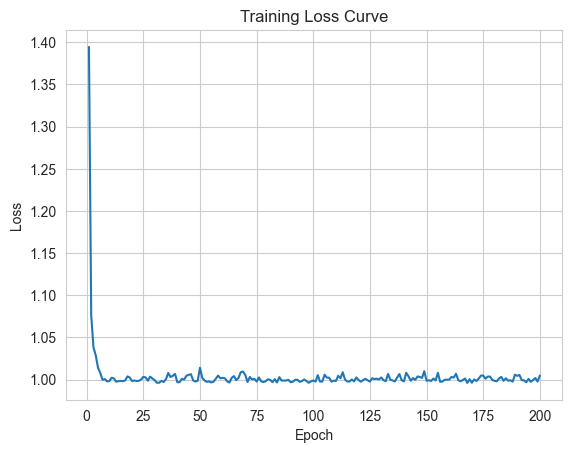

In [28]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_regression_r2score():
    model.eval()
    
    y_true_train, y_pred_train = [], []
    y_true_test, y_pred_test = [], []
    
    with torch.no_grad():
        for batch_features, batch_labels in train_dataloader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                preds =  model(batch_features).detach().cpu().numpy()
                y_pred_train.extend(preds)
                y_true_train.extend(batch_labels.cpu().numpy())
            
    with torch.no_grad():
        for batch_features, batch_labels in test_dataloader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                preds =  model(batch_features).detach().cpu().numpy()
                y_pred_test.extend(preds)
                y_true_test.extend(batch_labels.cpu().numpy())
            
    # Convert to numpy arrays
    y_true_train = np.array(y_true_train)
    y_pred_train = np.array(y_pred_train)
    y_true_test = np.array(y_true_test)
    y_pred_test = np.array(y_pred_test)
                
    train_mse = mean_squared_error(y_true_train, y_pred_train)
    test_mse = mean_squared_error(y_true_test, y_pred_test)
            
    train_r2 = r2_score(y_true_train, y_pred_train)
    test_r2 = r2_score(y_true_test, y_pred_test)
    
    return {
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

In [30]:
evaluate_regression_r2score()

{'Train MSE': 1.0001176595687866,
 'Test MSE': 0.04430439695715904,
 'Train R2': -0.0001176595687866211,
 'Test R2': -0.024759650230407715}